In [2]:
# ============================================================
# 02_Visualisations_Unilever.ipynb
# Unilever FY2023 — Budget vs Actual Visualisations
# Data loaded from Phase 1 output CSV
# ============================================================

import pandas as pd

# Load dataset saved in Phase 1
df = pd.read_csv('unilever_bat_2023_final.csv')

# Confirm it loaded correctly
print(df.shape)
print(df.head())

(7, 6)
                           Unnamed: 0  2023_Budget  2023_Actual  Variance_Abs  \
0                       Total Revenue      57400.0      51680.0       -5720.0   
1                     Cost Of Revenue      32100.0      29180.0       -2920.0   
2                        Gross Profit      25300.0      22500.0       -2800.0   
3  Selling General And Administration      13700.0      13346.0        -354.0   
4                    Operating Income       9800.0       9275.0        -525.0   

   Variance_Pct F_or_A  
0         -10.0      A  
1          -9.1      F  
2         -11.1      A  
3          -2.6      F  
4          -5.4      A  


In [4]:
# ============================================================
# Data Cleaning — fix index and shorten labels
# ============================================================

# Rename the unnamed column to something meaningful
df = df.rename(columns={'Unnamed: 0': 'Line_Item'})

# Set Line_Item as the index
df = df.set_index('Line_Item')

# Shorten the SG&A label for cleaner chart display
df = df.rename(index={'Selling General And Administration': 'SG&A'})

# Confirm
print(df)

                  2023_Budget  2023_Actual  Variance_Abs  Variance_Pct F_or_A
Line_Item                                                                    
Total Revenue         57400.0      51680.0       -5720.0         -10.0      A
Cost Of Revenue       32100.0      29180.0       -2920.0          -9.1      F
Gross Profit          25300.0      22500.0       -2800.0         -11.1      A
SG&A                  13700.0      13346.0        -354.0          -2.6      F
Operating Income       9800.0       9275.0        -525.0          -5.4      A
EBITDA                12900.0      10730.0       -2170.0         -16.8      A
Net Income             6800.0       6487.0        -313.0          -4.6      A


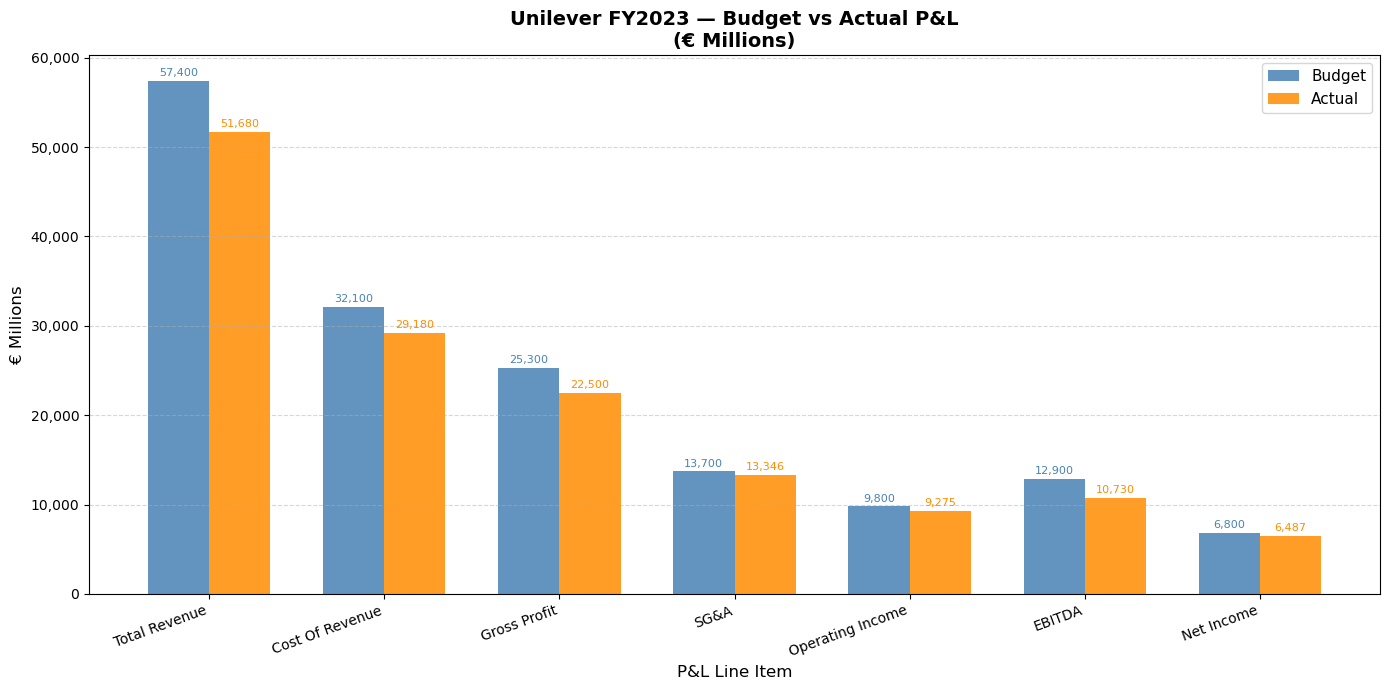

Chart 1 saved.


In [12]:
# ============================================================
# Chart 1: Budget vs Actual — Grouped Bar Chart
# Unilever FY2023 P&L Variance Analysis
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# --- Pull data directly from df ---
line_items = df.index.tolist()
budget     = df['2023_Budget'].tolist()
actual     = df['2023_Actual'].tolist()

x     = np.arange(len(line_items))  # x position for each group
width = 0.35                         # width of each individual bar

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 7))

bars_budget = ax.bar(x - width/2, budget, width,
                     label='Budget', color='steelblue', alpha=0.85)
bars_actual = ax.bar(x + width/2, actual, width,
                     label='Actual', color='darkorange', alpha=0.85)

# --- Value labels on top of each bar ---
for bar in bars_budget:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 300,
            f'{bar.get_height():,.0f}',
            ha='center', va='bottom', fontsize=8, color='steelblue')

for bar in bars_actual:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 300,
            f'{bar.get_height():,.0f}',
            ha='center', va='bottom', fontsize=8, color='darkorange')

# --- Formatting ---
ax.set_xlabel('P&L Line Item', fontsize=12)
ax.set_ylabel('€ Millions', fontsize=12)
ax.set_title('Unilever FY2023 — Budget vs Actual P&L\n(€ Millions)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(line_items, rotation=20, ha='right', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'{val:,.0f}'))
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('chart1_budget_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart 1 saved.")

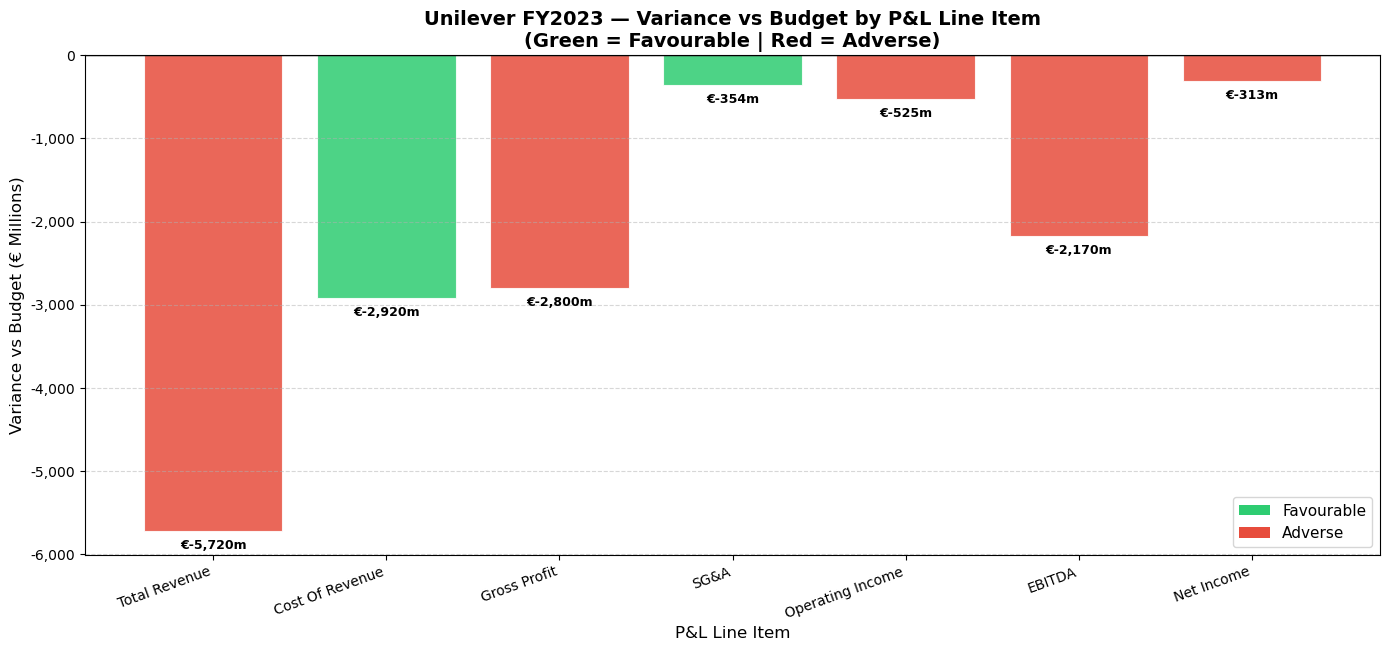

Chart 2 saved.


In [18]:
# ============================================================
# Chart 2: Variance Waterfall Chart
# Shows Adverse (red) and Favourable (green) variances
# ============================================================

# --- Data from df ---
line_items  = df.index.tolist()
variances   = df['Variance_Abs'].tolist()
flags       = df['F_or_A'].tolist()

# --- Colour each bar: green = Favourable, red = Adverse ---
colors = ['#2ecc71' if f == 'F' else '#e74c3c' for f in flags]

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(line_items, variances, color=colors, alpha=0.85, edgecolor='white', linewidth=0.8)

# --- Value labels on each bar ---
for bar, val in zip(bars, variances):
    vertical_offset = 80 if val >= 0 else -250
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + vertical_offset,
            f'€{val:,.0f}m',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- Reference line at zero ---
ax.axhline(0, color='black', linewidth=1.0, linestyle='-')

# --- Formatting ---
ax.set_xlabel('P&L Line Item', fontsize=12)
ax.set_ylabel('Variance vs Budget (€ Millions)', fontsize=12)
ax.set_title('Unilever FY2023 — Variance vs Budget by P&L Line Item\n(Green = Favourable | Red = Adverse)',
             fontsize=14, fontweight='bold')
ax.set_xticks(range(len(line_items)))
ax.set_xticklabels(line_items, rotation=20, ha='right', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'{val:,.0f}'))
ax.grid(axis='y', linestyle='--', alpha=0.5)

# --- Custom legend ---
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Favourable'),
                   Patch(facecolor='#e74c3c', label='Adverse')]
ax.legend(handles=legend_elements, fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.savefig('chart2_variance_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart 2 saved.")


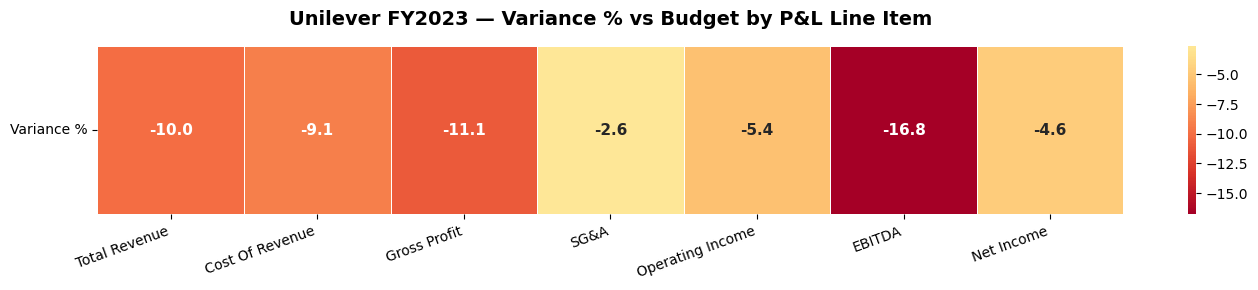

Chart 3 saved.


In [20]:
# ============================================================
# Chart 3: Variance Heatmap
# Unilever FY2023 — Variance % by P&L Line Item
# ============================================================

import seaborn as sns

# --- Prepare data for heatmap (needs a 2D array) ---
heatmap_data = df[['Variance_Pct']].T  # Transpose so line items are columns

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 3))

sns.heatmap(heatmap_data,
            annot=True,
            fmt='.1f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            linecolor='white',
            ax=ax,
            annot_kws={'size': 11, 'weight': 'bold'})

# --- Formatting ---
ax.set_title('Unilever FY2023 — Variance % vs Budget by P&L Line Item',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(df.index.tolist(), rotation=20, ha='right', fontsize=10)
ax.set_yticklabels(['Variance %'], rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('chart3_variance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart 3 saved.")

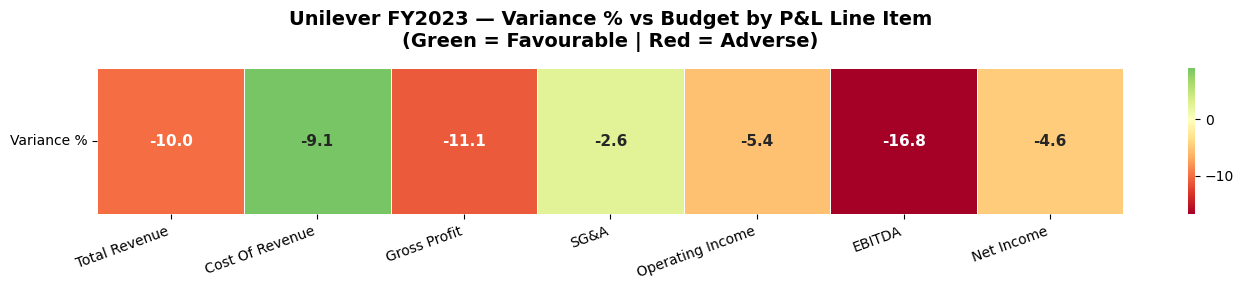

Chart 3 saved.


In [22]:
# ============================================================
# Chart 3: Variance Heatmap — with correct F/A colour logic
# ============================================================

import seaborn as sns

# --- Adjust sign for cost lines so heatmap colours are meaningful ---
# For cost lines, a negative variance is FAVOURABLE (green)
# We flip the sign so the heatmap treats them correctly

heatmap_values = df['Variance_Pct'].copy()
cost_lines = ['Cost Of Revenue', 'SG&A']
heatmap_values[cost_lines] = heatmap_values[cost_lines] * -1

heatmap_data = heatmap_values.to_frame().T

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 3))

sns.heatmap(heatmap_data,
            annot=df[['Variance_Pct']].T,  # show original values as labels
            fmt='.1f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            linecolor='white',
            ax=ax,
            annot_kws={'size': 11, 'weight': 'bold'})

ax.set_title('Unilever FY2023 — Variance % vs Budget by P&L Line Item\n(Green = Favourable | Red = Adverse)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(df.index.tolist(), rotation=20, ha='right', fontsize=10)
ax.set_yticklabels(['Variance %'], rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('chart3_variance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart 3 saved.")